### ДЗ_4 RandomForest

#### Задание:

* В ноутбуке реализовать визуализацию объектов используемых для обучения случайного леса
* Реализовать обучение случайного леса при помощи библиотеки sklearn (RandomForest)
* Сформировать с помощью sklearn.make_classification датасет из 1000 объектов с двумя признаками, обучить случайный лес из 1, 3, 10 и 50, 100, 200 деревьев и визуализировать их разделяющие гиперплоскости на графиках (по подобию визуализации деревьев из предыдущего урока, необходимо только заменить вызов функции predict на tree_vote). Сделать выводы о получаемой сложности гиперплоскости и недообучении или переобучении случайного леса в зависимости от количества деревьев в нем.
* (По желанию) Заменить в реализованном алгоритме проверку с помощью отложенной выборки на Out-of-Bag.

In [1]:
import matplotlib.pyplot as plt
import random

from matplotlib.colors import ListedColormap
from sklearn import datasets

import numpy as np

In [2]:
# сгенерируем данные, представляющие собой 500 объектов с 2-мя признаками
classification_data, classification_labels = datasets.make_classification(
    n_samples=1000,
    n_features = 2,
    n_informative = 2,
    n_classes = 2,
    n_redundant=0,
    n_clusters_per_class=1,
    flip_y = 0.05,
    random_state=5
)

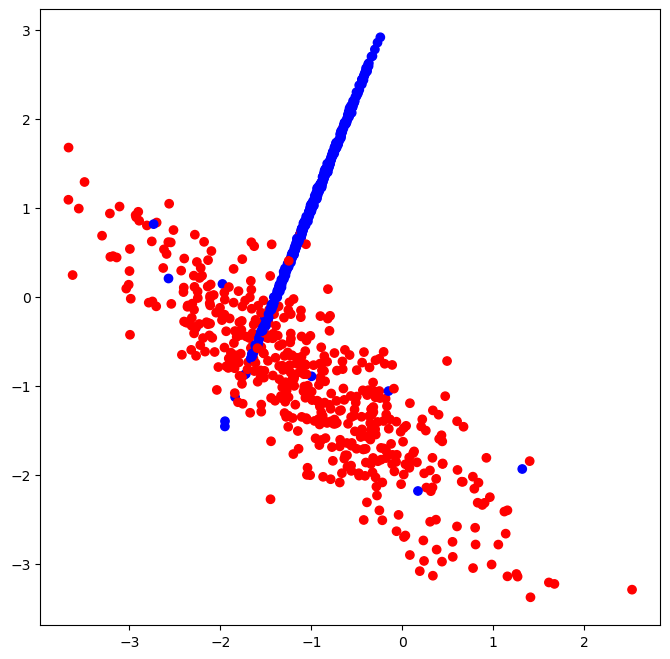

In [3]:
# визуализируем сгенерированные данные

colors = ListedColormap(['red', 'blue'])
light_colors = ListedColormap(['lightcoral', 'lightblue'])

plt.figure(figsize=(8,8))
plt.scatter(list(map(lambda x: x[0], classification_data)), list(map(lambda x: x[1], classification_data)), 
              c=classification_labels, cmap=colors)

In [4]:
random.seed(42)
 
def get_bootstrap(data, labels, N):
    n_samples = data.shape[0]
    bootstrap = []
    
    for i in range(N):
        b_data = np.zeros(data.shape)
        b_labels = np.zeros(labels.shape)
        for j in range(n_samples):
            sample_index = random.randint(0, n_samples-1)
            b_data[j] = data[sample_index]
            b_labels[j] = labels[sample_index]            
        bootstrap.append((b_data, b_labels))
        
    return bootstrap

In [5]:
def get_subsample(len_sample):
    # будем сохранять не сами признаки, а их индексы
    sample_indexes = [i for i in range(len_sample)]
    
    len_subsample = int(np.sqrt(len_sample))
    subsample = []
    
    random.shuffle(sample_indexes)
    for _ in range(len_subsample):
        subsample.append(sample_indexes.pop())
        
    return subsample

In [6]:
# Реализуем класс узла

class Node:
    
    def __init__(self, index, t, true_branch, false_branch):
        self.index = index  # индекс признака, по которому ведется сравнение с порогом в этом узле
        self.t = t  # значение порога
        self.true_branch = true_branch  # поддерево, удовлетворяющее условию в узле
        self.false_branch = false_branch  # поддерево, не удовлетворяющее условию в узле

In [7]:
# И класс терминального узла (листа)

class Leaf:
    
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels
        self.prediction = self.predict()
        
    def predict(self):
        # подсчет количества объектов разных классов
        classes = {}  # сформируем словарь "класс: количество объектов"
        for label in self.labels:
            if label not in classes:
                classes[label] = 0
            classes[label] += 1
        #  найдем класс, количество объектов которого будет максимальным в этом листе и вернем его    
        prediction = max(classes, key=classes.get)
        return prediction        

In [8]:
# Расчет критерия Джини

def gini(labels):
    #  подсчет количества объектов разных классов
    classes = {}
    for label in labels:
        if label not in classes:
            classes[label] = 0
        classes[label] += 1
    
    #  расчет критерия
    impurity = 1
    for label in classes:
        p = classes[label] / len(labels)
        impurity -= p ** 2
        
    return impurity

In [9]:
# Расчет качества

def quality(left_labels, right_labels, current_gini):

    # доля выбоки, ушедшая в левое поддерево
    p = float(left_labels.shape[0]) / (left_labels.shape[0] + right_labels.shape[0])
    
    return current_gini - p * gini(left_labels) - (1 - p) * gini(right_labels)

In [10]:
# Разбиение датасета в узле

def split(data, labels, index, t):
    
    left = np.where(data[:, index] <= t)
    right = np.where(data[:, index] > t)
        
    true_data = data[left]
    false_data = data[right]
    true_labels = labels[left]
    false_labels = labels[right]
        
    return true_data, false_data, true_labels, false_labels

In [11]:
# Нахождение наилучшего разбиения

def find_best_split(data, labels):
    
    #  обозначим минимальное количество объектов в узле
    min_leaf = 1

    current_gini = gini(labels)

    best_quality = 0
    best_t = None
    best_index = None
    
    n_features = data.shape[1]
    
    # выбор индекса из подвыборки длиной sqrt(n_features)
    subsample = get_subsample(n_features)
    
    for index in subsample:
        # будем проверять только уникальные значения признака, исключая повторения
        t_values = np.unique([row[index] for row in data])
        
        for t in t_values:
            true_data, false_data, true_labels, false_labels = split(data, labels, index, t)
            #  пропускаем разбиения, в которых в узле остается менее 5 объектов
            if len(true_data) < min_leaf or len(false_data) < min_leaf:
                continue
            
            current_quality = quality(true_labels, false_labels, current_gini)
            
            #  выбираем порог, на котором получается максимальный прирост качества
            if current_quality > best_quality:
                best_quality, best_t, best_index = current_quality, t, index

    return best_quality, best_t, best_index

In [12]:
# Построение дерева с помощью рекурсивной функции

def build_tree(data, labels):

    quality, t, index = find_best_split(data, labels)

    #  Базовый случай - прекращаем рекурсию, когда нет прироста в качества
    if quality == 0:
        return Leaf(data, labels)

    true_data, false_data, true_labels, false_labels = split(data, labels, index, t)

    # Рекурсивно строим два поддерева
    true_branch = build_tree(true_data, true_labels)
    false_branch = build_tree(false_data, false_labels)

    # Возвращаем класс узла со всеми поддеревьями, то есть целого дерева
    return Node(index, t, true_branch, false_branch)

In [13]:
def random_forest(data, labels, n_trees):
    forest = []
    bootstrap = get_bootstrap(data, labels, n_trees)
    
    for b_data, b_labels in bootstrap:
        forest.append(build_tree(b_data, b_labels))
        
    return forest

In [14]:
# Функция классификации отдельного объекта

def classify_object(obj, node):

    #  Останавливаем рекурсию, если достигли листа
    if isinstance(node, Leaf):
        answer = node.prediction
        return answer

    if obj[node.index] <= node.t:
        return classify_object(obj, node.true_branch)
    else:
        return classify_object(obj, node.false_branch)

In [15]:
# функция формирования предсказания по выборке на одном дереве

def predict(data, tree):
    
    classes = []
    for obj in data:
        prediction = classify_object(obj, tree)
        classes.append(prediction)
    return classes

In [16]:
# предсказание голосованием деревьев

def tree_vote(forest, data):

    # добавим предсказания всех деревьев в список
    predictions = []
    for tree in forest:
        predictions.append(predict(data, tree))
    
    # сформируем список с предсказаниями для каждого объекта
    predictions_per_object = list(zip(*predictions))
    
    # выберем в качестве итогового предсказания для каждого объекта то,
    # за которое проголосовало большинство деревьев
    voted_predictions = []
    for obj in predictions_per_object:
        voted_predictions.append(max(set(obj), key=obj.count))
        
    return voted_predictions

Далее мы сделаем обычное разбиение выборки на обучающую и тестовую, как это делалось ранее. Оценить ошибку этого же алгоритма по методу Out-of-Bag будет вашим домашним заданием к этому уроку.

In [17]:
# Разобьем выборку на обучающую и тестовую

from sklearn import model_selection

train_data, test_data, train_labels, test_labels = model_selection.train_test_split(classification_data, 
                                                                                     classification_labels, 
                                                                                     test_size = 0.3,
                                                                                     random_state = 1)

In [18]:
len(train_data)

700

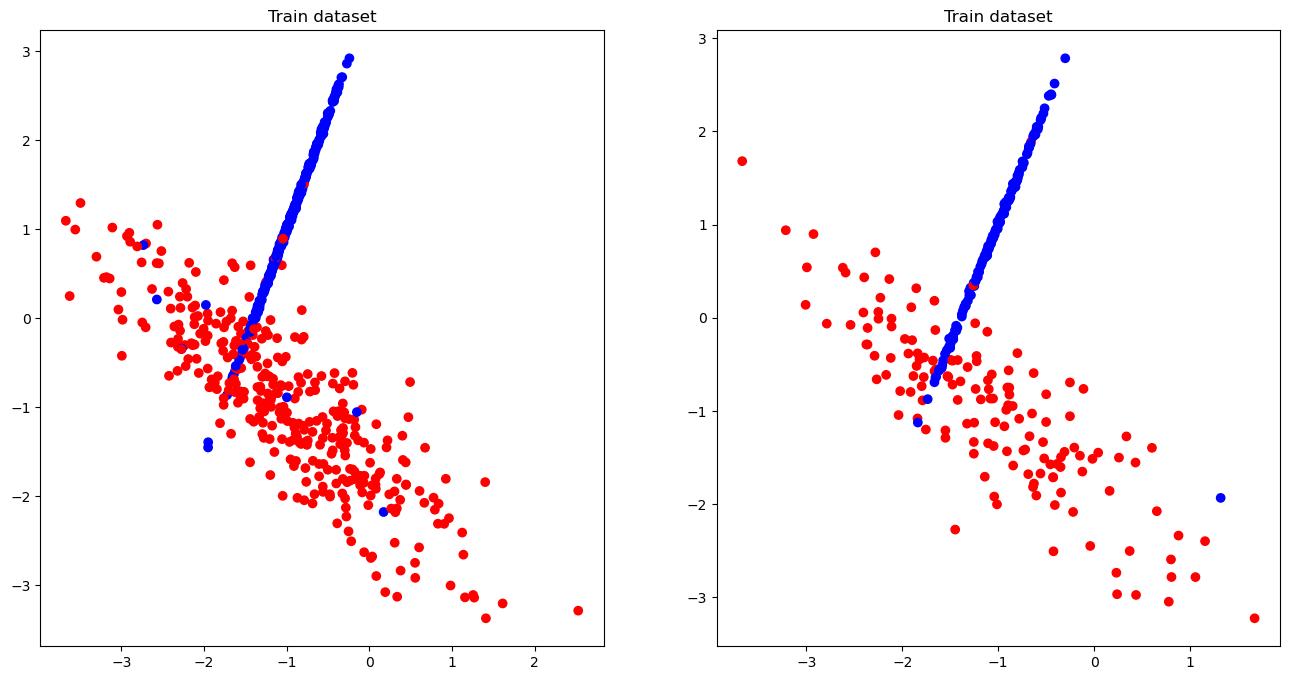

In [19]:
# визуализируем сгенерированные данные

colors = ListedColormap(['red', 'blue'])
light_colors = ListedColormap(['lightcoral', 'lightblue'])

plt.figure(figsize=(16,8))
plt.subplot(121)
plt.title("Train dataset")
plt.scatter(list(map(lambda x: x[0], train_data)), list(map(lambda x: x[1], train_data)), 
              c=train_labels, cmap=colors)
plt.subplot(122)
plt.title("Train dataset")
plt.scatter(list(map(lambda x: x[0], test_data)), list(map(lambda x: x[1], test_data)), 
              c=test_labels, cmap=colors)

In [20]:
  # Введем функцию подсчета точности как доли правильных ответов

def accuracy_metric(actual, predicted):
    correct = 0
    for i in range(len(actual)):
        if actual[i] == predicted[i]:
              correct += 1
    return correct / float(len(actual))*100.0

Теперь построим несколько случайных лесов с разным количеством деревьев в них.

Построим лес из одного дерева

In [21]:
n_trees = 1
my_forest_1 = random_forest(train_data, train_labels, n_trees)

In [22]:
# Получим ответы для обучающей выборки 
train_answers = tree_vote(my_forest_1, train_data)

In [23]:
# И получим ответы для тестовой выборки
test_answers = tree_vote(my_forest_1, test_data)

In [24]:
# Точность на обучающей выборке
train_accuracy = accuracy_metric(train_labels, train_answers)
print(f'Точность случайного леса из {n_trees} деревьев на обучающей выборке: {train_accuracy:.3f}')

Точность случайного леса из 1 деревьев на обучающей выборке: 97.000


In [25]:
# Точность на тестовой выборке
test_accuracy = accuracy_metric(test_labels, test_answers)
print(f'Точность случайного леса из {n_trees} деревьев на тестовой выборке: {test_accuracy:.3f}')

Точность случайного леса из 1 деревьев на тестовой выборке: 92.000


Построим лес из трех деревьев

In [26]:
n_trees = 3
my_forest_3 = random_forest(train_data, train_labels, n_trees)

In [27]:
# Получим ответы для обучающей выборки 
train_answers = tree_vote(my_forest_3, train_data)

In [28]:
# И получим ответы для тестовой выборки
test_answers = tree_vote(my_forest_3, test_data)

In [29]:
# Точность на обучающей выборке
train_accuracy = accuracy_metric(train_labels, train_answers)
print(f'Точность случайного леса из {n_trees} деревьев на обучающей выборке: {train_accuracy:.3f}')

Точность случайного леса из 3 деревьев на обучающей выборке: 98.143


In [30]:
# Точность на тестовой выборке
test_accuracy = accuracy_metric(test_labels, test_answers)
print(f'Точность случайного леса из {n_trees} деревьев на тестовой выборке: {test_accuracy:.3f}')

Точность случайного леса из 3 деревьев на тестовой выборке: 94.667


Построим лес из десяти деревьев

In [31]:
n_trees = 10
my_forest_10 = random_forest(train_data, train_labels, n_trees)

In [32]:
# Получим ответы для обучающей выборки 
train_answers = tree_vote(my_forest_10, train_data)

In [33]:
# И получим ответы для тестовой выборки
test_answers = tree_vote(my_forest_10, test_data)

In [34]:
# Точность на обучающей выборке
train_accuracy = accuracy_metric(train_labels, train_answers)
print(f'Точность случайного леса из {n_trees} деревьев на обучающей выборке: {train_accuracy:.3f}')

Точность случайного леса из 10 деревьев на обучающей выборке: 99.429


In [35]:
# Точность на тестовой выборке
test_accuracy = accuracy_metric(test_labels, test_answers)
print(f'Точность случайного леса из {n_trees} деревьев на тестовой выборке: {test_accuracy:.3f}')

Точность случайного леса из 10 деревьев на тестовой выборке: 94.333


Построим лес из пятидесяти деревьев

In [36]:
n_trees = 50
my_forest_50 = random_forest(train_data, train_labels, n_trees)

In [37]:
# Получим ответы для обучающей выборки 
train_answers = tree_vote(my_forest_50, train_data)


In [38]:
# И получим ответы для тестовой выборки
test_answers = tree_vote(my_forest_50, test_data)

In [39]:
# Точность на обучающей выборке
train_accuracy = accuracy_metric(train_labels, train_answers)
print(f'Точность случайного леса из {n_trees} деревьев на обучающей выборке: {train_accuracy:.3f}')

Точность случайного леса из 50 деревьев на обучающей выборке: 100.000


In [40]:
# Точность на тестовой выборке
test_accuracy = accuracy_metric(test_labels, test_answers)
print(f'Точность случайного леса из {n_trees} деревьев на тестовой выборке: {test_accuracy:.3f}')

Точность случайного леса из 50 деревьев на тестовой выборке: 95.000


In [41]:
from sklearn.ensemble import RandomForestClassifier

results_sklearn = []
for n_trees in [1, 3, 10, 50, 100, 200]:
    model = RandomForestClassifier(
        n_estimators=n_trees,
        min_samples_leaf=5,
        random_state=27,
    )
    model.fit(train_data, train_labels)
    y_pred_test = model.predict(test_data)
    y_pred_train = model.predict(train_data)

    test_score = accuracy_metric(test_labels, y_pred_test)
    train_score = accuracy_metric(train_labels, y_pred_train)

    results_sklearn.append({
            'n_trees': n_trees,
            'train_score': train_score,
            'test_score': test_score,
            'model': model
    })
    
    print(f'Точность случайного леса из {n_trees} деревьев на тестовой выборке {test_score:.3f}')
    print(f'Точность случайного леса из {n_trees} деревьев на обучающей выборке {train_score:.3f}')
    print('*'*60)

Точность случайного леса из 1 деревьев на тестовой выборке 88.667
Точность случайного леса из 1 деревьев на обучающей выборке 93.429
************************************************************
Точность случайного леса из 3 деревьев на тестовой выборке 95.333
Точность случайного леса из 3 деревьев на обучающей выборке 96.000
************************************************************
Точность случайного леса из 10 деревьев на тестовой выборке 93.667
Точность случайного леса из 10 деревьев на обучающей выборке 96.286
************************************************************
Точность случайного леса из 50 деревьев на тестовой выборке 93.333
Точность случайного леса из 50 деревьев на обучающей выборке 96.714
************************************************************
Точность случайного леса из 100 деревьев на тестовой выборке 94.000
Точность случайного леса из 100 деревьев на обучающей выборке 97.000
************************************************************
Точность случайного ле


5. Визуализация разделяющих гиперплоскостей (sklearn)


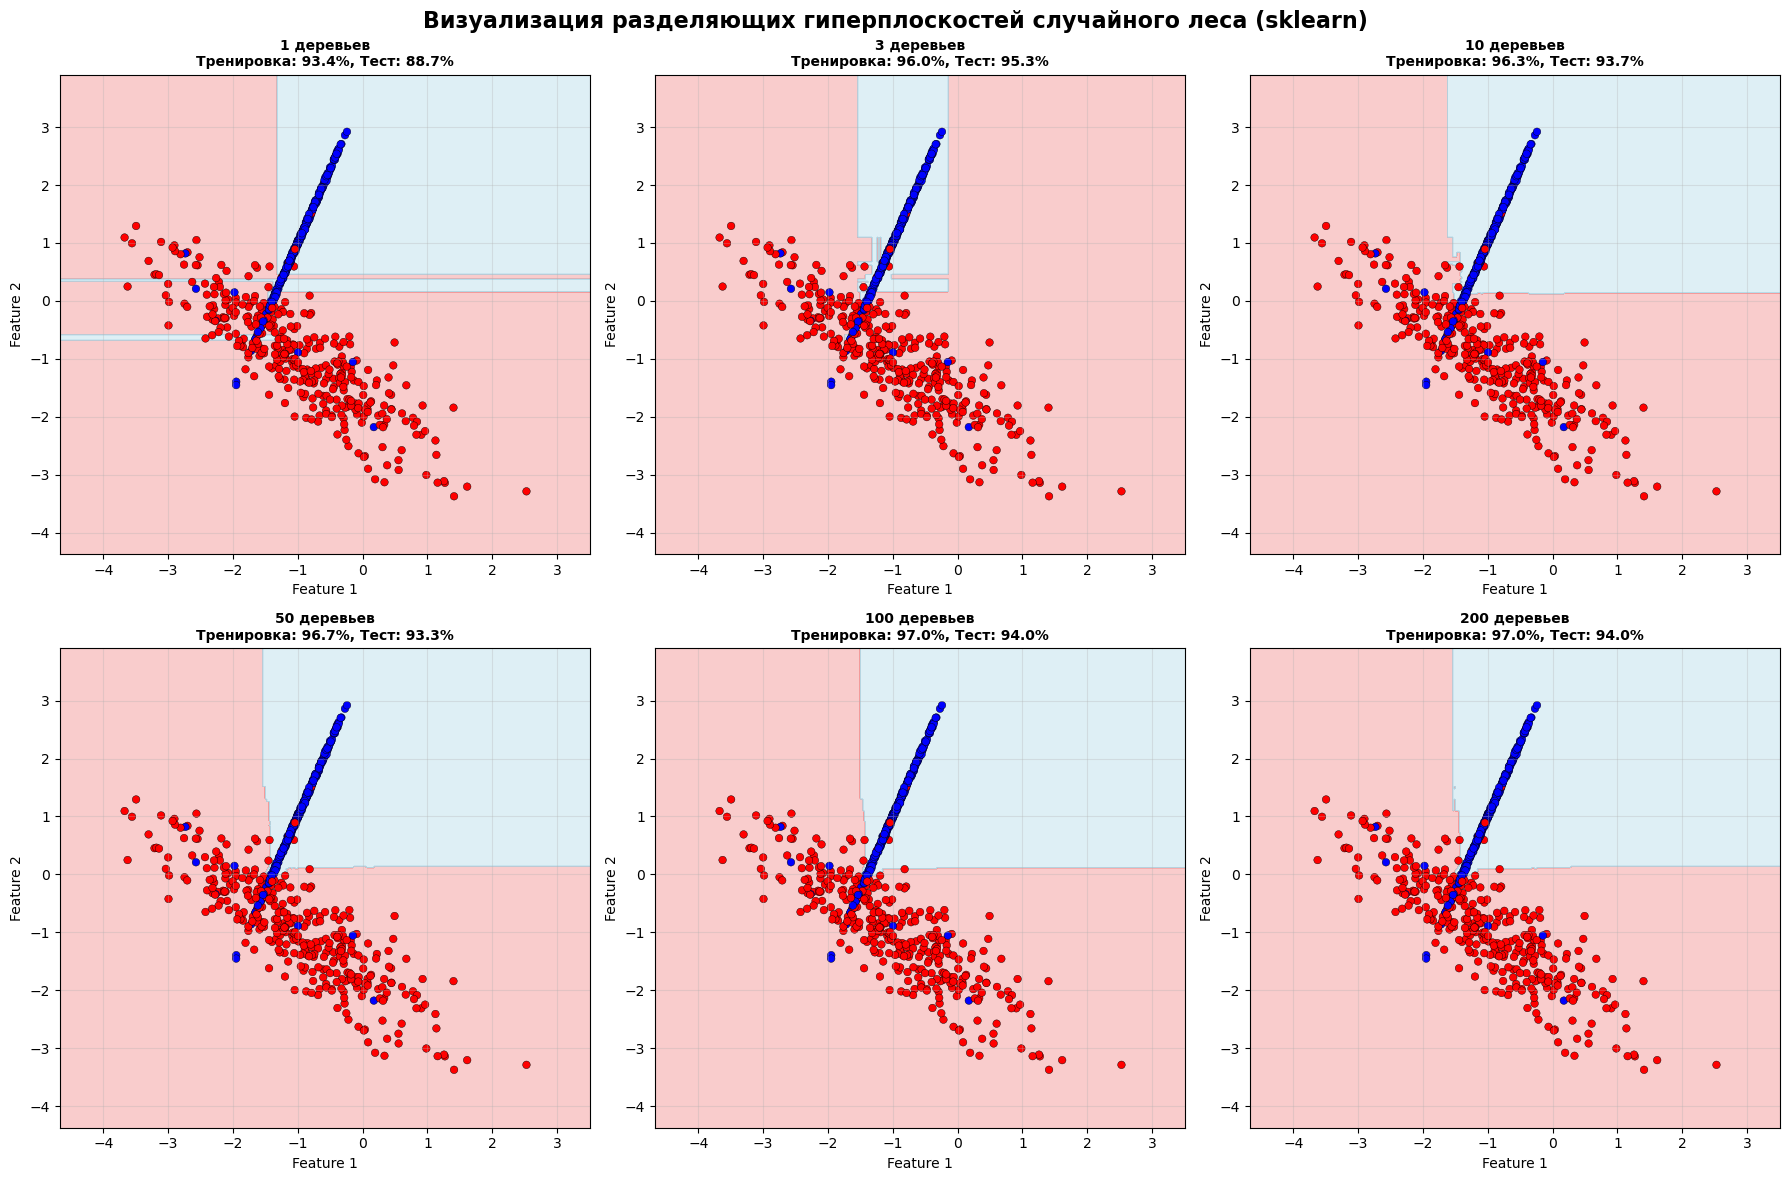

In [42]:
# 3. Визуализация разделяющих гиперплоскостей для sklearn моделей
print("\n" + "=" * 80)
print("5. Визуализация разделяющих гиперплоскостей (sklearn)")
print("=" * 80)
    
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Визуализация разделяющих гиперплоскостей случайного леса (sklearn)', 
                 fontsize=16, fontweight='bold')
    
for idx, result in enumerate(results_sklearn):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
        
    n_trees = result['n_trees']
    model = result['model']
        
    # Создаем сетку
    h = 0.02
    x_min, x_max = train_data[:, 0].min() - 1, train_data[:, 0].max() + 1
    y_min, y_max = train_data[:, 1].min() - 1, train_data[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))
        
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)
        
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=light_colors)
    ax.scatter(train_data[:, 0], train_data[:, 1], c=train_labels, cmap=colors, 
                  s=30, edgecolors='black', linewidth=0.3)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(f'{n_trees} деревьев\n'
                    f'Тренировка: {result["train_score"]:.1f}%, '
                    f'Тест: {result["test_score"]:.1f}%',
                    fontsize=10, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.3)
    
plt.tight_layout()
plt.savefig('decision_boundaries_sklearn.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
from sklearn.metrics import accuracy_score


def accuracy_metric(actual, predicted):
    print(f"Actual: {actual[:10]}")    # Первые 10 элементов
    print(f"Predicted: {predicted[:10]}")
    
    correct = 0
    for i in range(len(actual)):
        if actual[i] != predicted[i]:
            print(f"Расхождение на элементе {i}: actual={actual[i]}, predicted={predicted[i]}")
        if actual[i] == predicted[i]:
            correct += 1
    return correct / len(actual)

# И сравните с sklearn
print("Custom accuracy:", accuracy_metric(train_labels, y_pred_train))
print("Sklearn accuracy:", accuracy_score(train_labels, y_pred_train))

Actual: [1 0 0 0 0 1 0 0 1 1]
Predicted: [1 0 0 0 0 1 0 0 1 1]
Расхождение на элементе 13: actual=1, predicted=0
Расхождение на элементе 50: actual=0, predicted=1
Расхождение на элементе 71: actual=1, predicted=0
Расхождение на элементе 165: actual=1, predicted=0
Расхождение на элементе 180: actual=1, predicted=0
Расхождение на элементе 228: actual=0, predicted=1
Расхождение на элементе 258: actual=0, predicted=1
Расхождение на элементе 266: actual=0, predicted=1
Расхождение на элементе 335: actual=1, predicted=0
Расхождение на элементе 355: actual=1, predicted=0
Расхождение на элементе 356: actual=1, predicted=0
Расхождение на элементе 372: actual=1, predicted=0
Расхождение на элементе 393: actual=0, predicted=1
Расхождение на элементе 498: actual=1, predicted=0
Расхождение на элементе 508: actual=1, predicted=0
Расхождение на элементе 528: actual=0, predicted=1
Расхождение на элементе 544: actual=1, predicted=0
Расхождение на элементе 628: actual=1, predicted=0
Расхождение на элемент

#### Вывод:
    1. СЛОЖНОСТЬ ГИПЕРПЛОСКОСТИ:
       - С увеличением количества деревьев разделяющая гиперплоскость становится более сложной
       - При малом количестве деревьев (1-3) граница более простая и гладкая
       - При большом количестве деревьев (50-200) граница становится более детализированной
       
    2. НЕДООБУЧЕНИЕ (UNDERFITTING):
       - Наблюдается при малом количестве деревьев (1-3)
       - Низкая точность как на обучающей, так и на тестовой выборке
       - Простая модель не может уловить сложные закономерности в данных
       
    3. ПЕРЕОБУЧЕНИЕ (OVERFITTING):
       - Наблюдается при большом количестве деревьев (50-200)
       - Высокая точность на обучающей выборке, но меньшая на тестовой
       - Разница между train и test accuracy увеличивается
       - Модель запоминает шум в обучающих данных
       
    4. ОПТИМАЛЬНОЕ КОЛИЧЕСТВО ДЕРЕВЬЕВ:
       - Обычно находится в диапазоне 10-50 деревьев
       - Баланс между сложностью модели и обобщающей способностью
       - Минимальная разница между train и test accuracy